# Sync up google environment

In [ ]:
import os
import pandas as pd
import glob
from google.colab import auth
from googleapiclient.discovery import build
from googleapiclient.errors import HttpError
from google.colab import drive

# ==========================================
# CONFIGURATION
# ==========================================
# Your shared folder ID
SHARED_FOLDER_ID = "10DG3jCbfSdkZ_IlZhbs3QAGHCGoPUVY6"
# The name of the shortcut in the teammate's Drive
SHORTCUT_NAME = "Group_Project_NHS_Maternity_Shared"

# ==========================================
# 1. HELPER FUNCTIONS
# ==========================================

def auto_setup_project():
    """Automatically creates the shortcut in the user's Drive if it doesn't exist."""
    print(f"🔄 Syncing project environment...")

    # Authenticate user
    try:
        auth.authenticate_user()
    except Exception:
        print("⚠️ Authentication failed or skipped (Ignore if running locally).")
        return

    service = build('drive', 'v3')

    try:
        # Check if shortcut already exists
        query = f"name = '{SHORTCUT_NAME}' and mimeType = 'application/vnd.google-apps.shortcut' and trashed = false"
        results = service.files().list(q=query, spaces='drive', fields='files(id, name)').execute()
        items = results.get('files', [])

        if not items:
            print(f"⚙️ New user detected. Creating shortcut...")
            shortcut_metadata = {
                'name': SHORTCUT_NAME,
                'mimeType': 'application/vnd.google-apps.shortcut',
                'shortcutDetails': {'targetId': SHARED_FOLDER_ID}
            }
            service.files().create(body=shortcut_metadata, fields='id').execute()
            print(f"✅ Success! Shortcut '{SHORTCUT_NAME}' added to your Drive root.")
        else:
            print(f"✅ Environment checked: Shortcut '{SHORTCUT_NAME}' already exists.")

    except HttpError as error:
        print(f"⚠️ API Warning: {error}")

def smart_read_csv(base_dir, target_filename):
    """
    Recursively searches for 'target_filename' inside 'base_dir' and its subfolders.
    Returns the dataframe if found, otherwise returns None.
    """
    search_pattern = os.path.join(base_dir, "**", target_filename)
    # recursive=True allows searching inside subfolders
    found_files = glob.glob(search_pattern, recursive=True)

    if found_files:
        print(f"   ✅ Found file: {found_files[0]}")
        return pd.read_csv(found_files[0], header=None)
    else:
        return None

# ==========================================
# 2. MAIN EXECUTION FLOW
# ==========================================

# A. Run Auto-Setup
auto_setup_project()

# B. Mount Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# C. Define the Base Directory
DATA_DIR = f"/content/drive/MyDrive/{SHORTCUT_NAME}"
print(f"\n📂 Search Root Locked: {DATA_DIR}")

# D. Define Filenames (Key = Variable Name, Value = Actual Filename)
files_to_find = {
    "delivery_number":       "hosp-epis-stat-mat-summary-tables-2425-summary-report-1.csv",
    "delivery_type_by_age":  "hosp-epis-stat-mat-summary-tables-2425-summary-report-5.csv",
    "delivery_type_by_year": "hosp-epis-stat-mat-hesnational-2024-25-method-of-delivery.csv"
}

# E. Search and Load Data
try:
    print(f"🕵️‍♀️ Starting smart search in {DATA_DIR}...")

    if not os.path.exists(DATA_DIR):
        raise FileNotFoundError(f"❌ Path not found: {DATA_DIR}. Please check if the shortcut was created.")

    # Load files using the smart function
    delivery_number = smart_read_csv(DATA_DIR, files_to_find["delivery_number"])
    delivery_type_by_age = smart_read_csv(DATA_DIR, files_to_find["delivery_type_by_age"])
    delivery_type_by_year = smart_read_csv(DATA_DIR, files_to_find["delivery_type_by_year"])

    # Validation
    if delivery_number is None or delivery_type_by_age is None or delivery_type_by_year is None:
        print("\n⚠️ SOME FILES WERE NOT FOUND. Listing all available files in folder:")
        print("-" * 50)
        file_count = 0
        for root, dirs, files in os.walk(DATA_DIR):
            for file in files:
                print(f"📁 Found: {file} \n   (Location: {root})")
                file_count += 1
        print("-" * 50)
        if file_count == 0:
            print("❌ Warning: The folder is empty! Please check the source folder content.")
    else:
        print("\n🎉 Success! All NHS data loaded.")
        print(f"Data Preview (Delivery Number shape): {delivery_number.shape}")

except Exception as e:
    print(f"❌ An error occurred: {e}")

🔄 Syncing project environment...


✅ Environment checked: Shortcut 'Group_Project_NHS_Maternity_Shared' already exists.

📂 Search Root Locked: /content/drive/MyDrive/Group_Project_NHS_Maternity_Shared
🕵️‍♀️ Starting smart search in /content/drive/MyDrive/Group_Project_NHS_Maternity_Shared...
   ✅ Found file: /content/drive/MyDrive/Group_Project_NHS_Maternity_Shared/data/hosp-epis-stat-mat-summary-tables-2425-summary-report-1.csv
   ✅ Found file: /content/drive/MyDrive/Group_Project_NHS_Maternity_Shared/data/hosp-epis-stat-mat-summary-tables-2425-summary-report-5.csv
   ✅ Found file: /content/drive/MyDrive/Group_Project_NHS_Maternity_Shared/data/hosp-epis-stat-mat-hesnational-2024-25-method-of-delivery.csv

🎉 Success! All NHS data loaded.
Data Preview (Delivery Number shape): (13, 12)


# Dataset: Millennium Cohort Study (Age 9 months, Sweep 1, 2001)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')

In [ ]:
# Dataset: Millennium Cohort Study (Age 9 months, Sweep 1, 2001)
# Load each dataset
# Load with raw codes (no label conversion)
df_interview=pd.read_stata(INTERVIEW, convert_categoricals=False) # type of delivery & parity (any other babies conceived)
df_derived=pd.read_stata(DERIVED, convert_categoricals=False) # maternal age (respondent age at birth of cohort member)
df_family=pd.read_stata(FAMILY, convert_categoricals=False) # deprivation ( DV McClements below 60% median poverty indicator)

# Save to CSV
df_interview.to_csv("mcs1_parent_interview.csv", index=False)
df_derived.to_csv("mcs1_parent_derived.csv", index=False)
df_family.to_csv("mcs1_family_derived.csv", index=False)
# All three files converted to CSV so can be viewed in pandas

In [ ]:
# Selecting the variables needed
interview=df_interview[["MCSID", "APDEWM0A","APOBCO00"]].copy()
derived=df_derived[["MCSID", "ADDAGB00"]].copy()
family=df_family[["MCSID", "ADMCPO00"]].copy()

In [ ]:
# Dataframes with variables renamed for clarity
interview.rename(columns={"APDEWM0A": "delivery_type",
                          "APOBCO00": "parity"}, inplace=True)
derived.rename(columns={"ADDAGB00":"maternal_age"}, inplace=True)
family.rename(columns={"ADMCPO00":"poverty_indicator"}, inplace=True)

In [ ]:
interview.head()

,MCSID,delivery_type,parity
0,M10001N,1.0,1.0
1,M10001N,-1.0,-1.0
2,M10002P,5.0,1.0
3,M10002P,-1.0,-1.0
4,M10007U,6.0,1.0


In [ ]:
derived.head()

,MCSID,maternal_age
0,M10001N,22
1,M10001N,25
2,M10002P,34
3,M10002P,31
4,M10007U,35


In [ ]:
family.head()

,MCSID,poverty_indicator
0,M10001N,0
1,M10002P,0
2,M10007U,0
3,M10008V,-1
4,M10011Q,1


In [ ]:
# Determining the values counted within delivery type for recoding
interview["delivery_type"].value_counts(dropna=False)

,count
delivery_type,
-1.0,13236
1.0,12661
6.0,2258
5.0,1732
3.0,970
2.0,734
4.0,53
52.0,34
85.0,23


In [ ]:
# Cleaning data:replacing non-substantiative values with np.nan
interview["delivery_type"]=interview["delivery_type"].replace([-1, -8, -9], np.nan)

In [ ]:
# Recoding delivery_type into descriptive categories relevant to the question
def recode_delivery(delivery_type):
    if delivery_type in [5,6]:
        return "Caesarean"
    elif delivery_type in [1, 2, 3, 4]:
        return "Vaginal"
    else:
        return np.nan
interview["delivery_group"] = interview["delivery_type"].apply(recode_delivery)
# Creating a new column called delivery_group and applying the recoding to each row it contains


In [ ]:
interview["parity"].value_counts(dropna=False)

,count
parity,
1.0,18381
-1.0,13236
2.0,95
-8.0,7
NaN,1


In [ ]:
# Cleaning parity data
interview["parity"]=interview["parity"].replace([-1, -8], np.nan)

In [ ]:
# Recoding parity
def recode_parity(parity):
    if parity == 1:
        return "First-time mother"
    elif parity == 2 :
        return "Not first-time mother"
    else:
        return np.nan
interview["parity_group"]=interview["parity"].apply(recode_parity)

In [ ]:
# Value counts showing how many births correspond to first time mother vs not
interview["parity_group"].value_counts()

,count
parity_group,
First-time mother,18381
Not first-time mother,95


### Note on Parity Variable

Initial exploration of the parity variable (APOBCO00: "Any other babies conceived") revealed an unexpected distribution:
- **18,381 cases (99.5%)** coded as "First-time mother"  
- **95 cases (0.5%)** coded as "Not first-time mother"

Investigation of the variable label indicates this measures **multiple births in the current pregnancy** (twins/triplets) rather than previous maternal birth history.

After determining this, a search of the data dictionary for MCS sweep 1 revealed there were no other appropriate variables to measure maternal parity.

Parity_group is therefore **excluded from analysis** because:
1. The available variable measures multiple births, not birth history
2. Insufficient sample size (n=157, 0.5%) for statistical inference  
3. No alternative parity measure exists in MCS Sweep 1

In [ ]:
derived["maternal_age"].value_counts(dropna=False)

,count
maternal_age,
31,2226
30,2216
32,2209
29,2197
33,1980
28,1976
34,1825
27,1707
35,1586


In [ ]:
# Cleaning maternal age
derived["maternal_age"]=derived["maternal_age"].replace(-2,np.nan)

In [ ]:
# Recoding maternal_age
def recode_maternal_age(maternal_age):
    if maternal_age < 20:
        return "Under 20"
    elif 20 <= maternal_age <= 29:
        return "20-29"
    elif 30 <= maternal_age <= 39:
        return "30-39"
    elif maternal_age >= 40:
        return "40+"
    else:
        return np.nan
derived["maternal_age_group"]=derived["maternal_age"].apply(recode_maternal_age)

In [ ]:
family["poverty_indicator"].value_counts(dropna=False)

,count
poverty_indicator,
0,10397
1,6525
-1,1610


In [ ]:
# Cleaning poverty indicator
family["poverty_indicator"]=family["poverty_indicator"].replace(-1, np.nan)

In [ ]:
# Recoding poverty indicator
def recode_poverty_indicator(poverty_indicator):
    if poverty_indicator == 0:
        return "Below 60% median income"
    if poverty_indicator == 1:
        return "Above 60% median income"
    else:
        return np.nan
family["poverty_group"]=family["poverty_indicator"].apply(recode_poverty_indicator)

In [ ]:
# Check indicies to determine how to combine the dataframes into one analytical dataset
interview.index

RangeIndex(start=0, stop=31720, step=1)

In [ ]:
derived.index

RangeIndex(start=0, stop=33869, step=1)

In [ ]:
family.index

RangeIndex(start=0, stop=18532, step=1)

In [ ]:
# Subsetting interview to include only the required variables excluding parity_group
interview_subset = interview[["MCSID", "delivery_group"]]

In [ ]:
# Merging interview, derived, and family data (excluding parity) for analysis

analytical = interview_subset.merge(derived, on="MCSID", how="inner")
analytical = analytical.merge(family, on="MCSID", how="inner")


In [ ]:
# Checking merge
analytical.head()

,MCSID,delivery_group,maternal_age,maternal_age_group,poverty_indicator,poverty_group
0,M10001N,Vaginal,22.0,20-29,0.0,Below 60% median income
1,M10001N,Vaginal,25.0,20-29,0.0,Below 60% median income
2,M10001N,NaN,22.0,20-29,0.0,Below 60% median income
3,M10001N,NaN,25.0,20-29,0.0,Below 60% median income
4,M10002P,Caesarean,34.0,30-39,0.0,Below 60% median income


In [ ]:
# Keeping only the necessary columns (parity group is excluded)
analytical = analytical[[
    "MCSID",
    "delivery_group",
    "maternal_age_group",
    "poverty_group"
]]

In [ ]:
analytical.head()

,MCSID,delivery_group,maternal_age_group,poverty_group
0,M10001N,Vaginal,20-29,Below 60% median income
1,M10001N,Vaginal,20-29,Below 60% median income
2,M10001N,NaN,20-29,Below 60% median income
3,M10001N,NaN,20-29,Below 60% median income
4,M10002P,Caesarean,30-39,Below 60% median income


In [ ]:
# Shows where the missing data is
analytical.isna().sum()

,0
MCSID,0
delivery_group,26596
maternal_age_group,57
poverty_group,4989


In [ ]:
# Number of rows before cleaning
len(analytical)

60245

In [ ]:
analytical = analytical.dropna(subset=[
    "delivery_group",
    "maternal_age_group",
    "poverty_group"
])

In [ ]:
# Number of rows after cleaning
len(analytical)

30672

In [ ]:
print("Number of rows removed by cleaning", (60245-30672))

Number of rows removed by cleaning 29573


In [ ]:
# Checks to see if data is presenting how we want it to
analytical.head()

,MCSID,delivery_group,maternal_age_group,poverty_group
0,M10001N,Vaginal,20-29,Below 60% median income
1,M10001N,Vaginal,20-29,Below 60% median income
4,M10002P,Caesarean,30-39,Below 60% median income
5,M10002P,Caesarean,30-39,Below 60% median income
8,M10007U,Caesarean,30-39,Below 60% median income


In [ ]:
analytical.shape

(30672, 4)

In [ ]:
analytical.columns

Index(['MCSID', 'delivery_group', 'maternal_age_group', 'poverty_group'], dtype='object')

**Descriptive Statistics**


In [ ]:
# Sample Charcateristics
print("Dataset: Millennium Cohort Study (Age 9 months, Sweep 1, 2001)")
print("Total number of births in analytical sample: 60245 (including missing values)")
print("Rows removed due to missing data: 29573")
print("Final analytical sample:", len(analytical),"(without missing values)")

Dataset: Millennium Cohort Study (Age 9 months, Sweep 1, 2001)
Total number of births in analytical sample: 60245 (including missing values)
Rows removed due to missing data: 29573
Final analytical sample: 30672 (without missing values)


In [ ]:
# Value counts showing how many births fall into the cs and vag categories
print(analytical["delivery_group"].value_counts())

delivery_group
Vaginal      23922
Caesarean     6750
Name: count, dtype: int64


In [ ]:
# Creating count dataframe for bar plot (delivery group)
delivery_group_counts=pd.DataFrame(analytical["delivery_group"].value_counts()).reset_index()
delivery_group_counts.columns=["delivery_group","count"]
print(delivery_group_counts)

  delivery_group  count
0        Vaginal  23922
1      Caesarean   6750


[Text(0, 0.5, 'Delivery group'),
 Text(0.5, 0, 'Count'),
 Text(0.5, 1.0, 'Distribution of births by delivery group')]

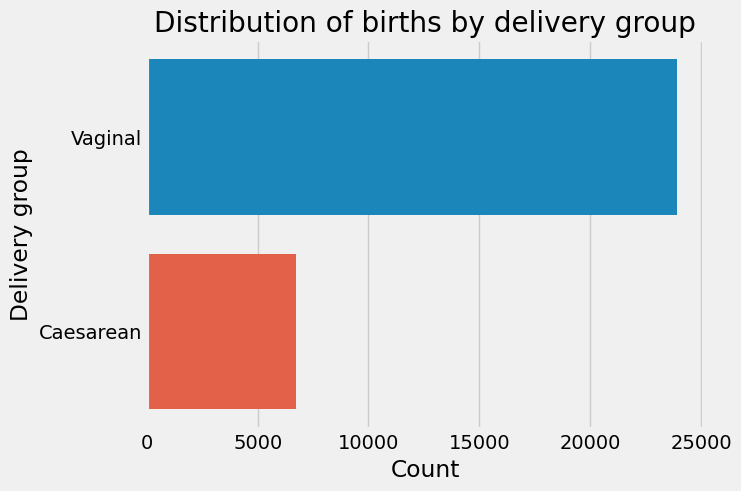

In [ ]:
# Bar plot for sample composition
delivery_group_barplot=sns.barplot(data=delivery_group_counts,x="count",y="delivery_group",hue="delivery_group")
delivery_group_barplot.set(ylabel="Delivery group",
                           xlabel="Count",
                           title="Distribution of births by delivery group")


*Figure 1. Bar chart showing the distribution of births across delivery groups in the analytical sample.*

In [ ]:
# Calculating the percentage of cs and vag births in the final analytical sample
overall_cs_rate=(analytical["delivery_group"]=="Caesarean").sum()/len(analytical)*100
overall_vag_rate=(analytical["delivery_group"]=="Vaginal").sum()/len(analytical)*100
print(
    "In the final analytical sample", round(overall_cs_rate,2), "% of births were caesarean and",
    round(overall_vag_rate,2), "% of births were vaginal."
)

In the final analytical sample 22.01 % of births were caesarean and 77.99 % of births were vaginal.


In [ ]:
# Value counts showing how many births all into each maternal age group
print(analytical["maternal_age_group"].value_counts())

maternal_age_group
30-39       14671
20-29       12570
Under 20     1725
40+          1706
Name: count, dtype: int64


In [ ]:
# Creating a count dataframe for bar plot (age group)
age_group_counts=pd.DataFrame(analytical["maternal_age_group"].value_counts()).reset_index()
age_group_counts.columns=["maternal_age_group","count"]

[Text(0, 0.5, 'Age group'),
 Text(0.5, 0, 'Count'),
 Text(0.5, 1.0, 'Distribution of births by age group')]

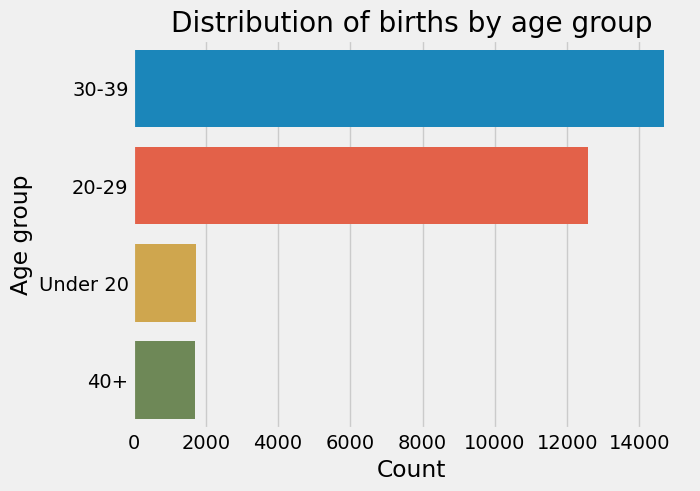

In [ ]:
# Creating the bar plot for sample composition
age_group_barplot=sns.barplot(data=age_group_counts,x="count",y="maternal_age_group",hue="maternal_age_group")
age_group_barplot.set(ylabel="Age group",
                          xlabel="Count",
                          title="Distribution of births by age group")


*Figure 2. Bar chart showing the distribution of births across maternal age groups in the analytical sample.*

In [ ]:
# Calculating the percentage of cs and vag births for each age group
age_groups=analytical["maternal_age_group"].unique()

for group in age_groups:
    subset=analytical[analytical["maternal_age_group"]==group]
    cs_rate=((subset["delivery_group"]=="Caesarean").sum()/len(subset))*100
    vag_rate=((subset["delivery_group"]=="Vaginal").sum()/len(subset))*100
    print(group,round(cs_rate,2),"% caesarean,",round(vag_rate,2),"% vaginal")


20-29 18.79 % caesarean, 81.21 % vaginal
30-39 25.05 % caesarean, 74.95 % vaginal
Under 20 12.52 % caesarean, 87.48 % vaginal
40+ 29.13 % caesarean, 70.87 % vaginal


In [ ]:
# Value counts showing how many births fall into each poverty group
print(analytical["poverty_group"].value_counts())

poverty_group
Below 60% median income    20214
Above 60% median income    10458
Name: count, dtype: int64


In [ ]:
# Creating a count df for bar plot (poverty group)
poverty_group_counts=pd.DataFrame(analytical["poverty_group"].value_counts()).reset_index()
poverty_group_counts.columns=["poverty_group","count"]

[Text(0, 0.5, 'Poverty group'),
 Text(0.5, 0, 'Count'),
 Text(0.5, 1.0, 'Distribution of births by poverty group')]

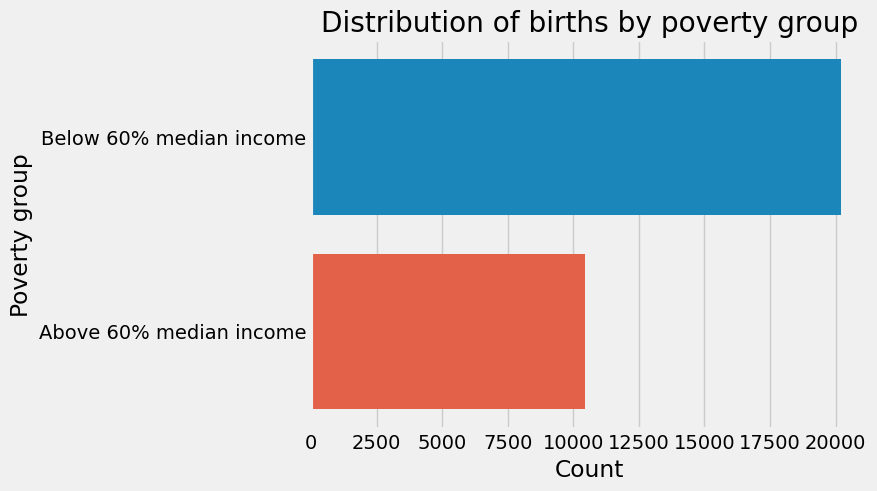

In [ ]:
# Creating the bar plot
poverty_group_barplot=sns.barplot(data=poverty_group_counts,x="count",y="poverty_group",hue="poverty_group")
poverty_group_barplot.set(ylabel="Poverty group",
                           xlabel="Count",
                           title="Distribution of births by poverty group")

*Figure 3. Bar chart showing the distribution of births across poverty groups in the analytical sample.*

In [ ]:
# Calculating the percentage of cs and vag births for each poverty group
poverty_groups=analytical["poverty_group"].unique()

for group in poverty_groups:
    subset=analytical[analytical["poverty_group"]==group]
    cs_rate=((subset["delivery_group"]=="Caesarean").sum()/len(subset))*100
    vag_rate=((subset["delivery_group"]=="Vaginal").sum()/len(subset))*100
    print(group,round(cs_rate,2),"% caesarean,",round(vag_rate,2),"% vaginal")

Below 60% median income 24.1 % caesarean, 75.9 % vaginal
Above 60% median income 17.96 % caesarean, 82.04 % vaginal


**Crosstabs and Stacked Bar Figures**

*Whilst these percentages were previously calculated using a loop, they are repeated here in tabular format to suppport visualisation via stacked bar plots.*
*Both raw counts and cross-tabulation percentages are reported. Raw counts show the size of the subgroup, whilst percentage allows for comparison of delivery type between the three subgroups: maternal age, poverty and parity.*


In [ ]:
# Counts for each age group broken down by delivery group
age_crosstab=pd.crosstab(analytical["maternal_age_group"], analytical["delivery_group"])
print(round(age_crosstab,2))


delivery_group      Caesarean  Vaginal
maternal_age_group                    
20-29                    2362    10208
30-39                    3675    10996
40+                       497     1209
Under 20                  216     1509


In [ ]:
#  Cross-tabulation of percetanges for maternal age groups (rows) and delivery group (columns)
age_crosstab_pct=pd.crosstab(analytical["maternal_age_group"],analytical["delivery_group"],normalize="index")*100
print(round(age_crosstab_pct,2))

delivery_group      Caesarean  Vaginal
maternal_age_group                    
20-29                   18.79    81.21
30-39                   25.05    74.95
40+                     29.13    70.87
Under 20                12.52    87.48


Text(0, 0.5, 'Percentage')

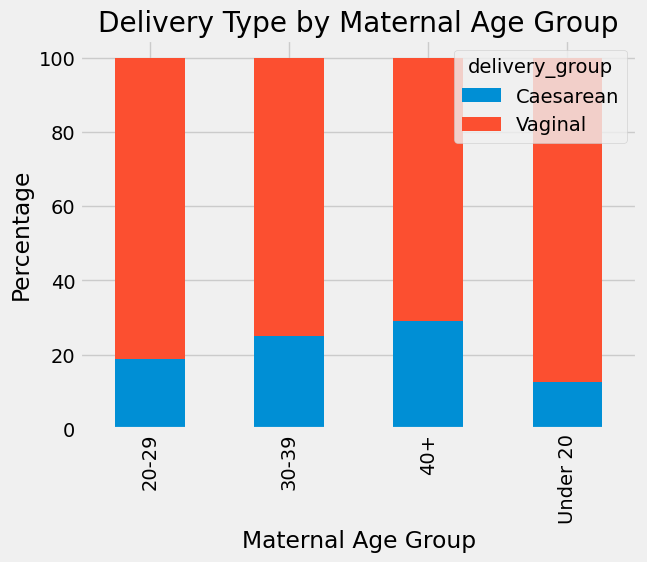

In [ ]:
# Stacked Bar Plot
age_crosstab_pct.plot(kind="bar",stacked=True)
plt.title("Delivery Type by Maternal Age Group")
plt.xlabel("Maternal Age Group")
plt.ylabel("Percentage")

*Figure 4. Stacked bar plot showing percentage distrubtion of delivery type across maternal age groups in the analytical sample.*

In [ ]:
# Counts for each poverty group broken down by delivery group
poverty_crosstab=pd.crosstab(analytical["poverty_group"],analytical["delivery_group"])
print(round(poverty_crosstab,2))

delivery_group           Caesarean  Vaginal
poverty_group                              
Above 60% median income       1878     8580
Below 60% median income       4872    15342


In [ ]:
# Cross-tabulation of percetanges for poverty groups (rows) and delivery group (columns)
poverty_crosstab_pct=pd.crosstab(analytical["poverty_group"],analytical["delivery_group"],normalize="index")*100
print(round(poverty_crosstab_pct,2))

delivery_group           Caesarean  Vaginal
poverty_group                              
Above 60% median income      17.96    82.04
Below 60% median income      24.10    75.90


Text(0, 0.5, 'Percentage')

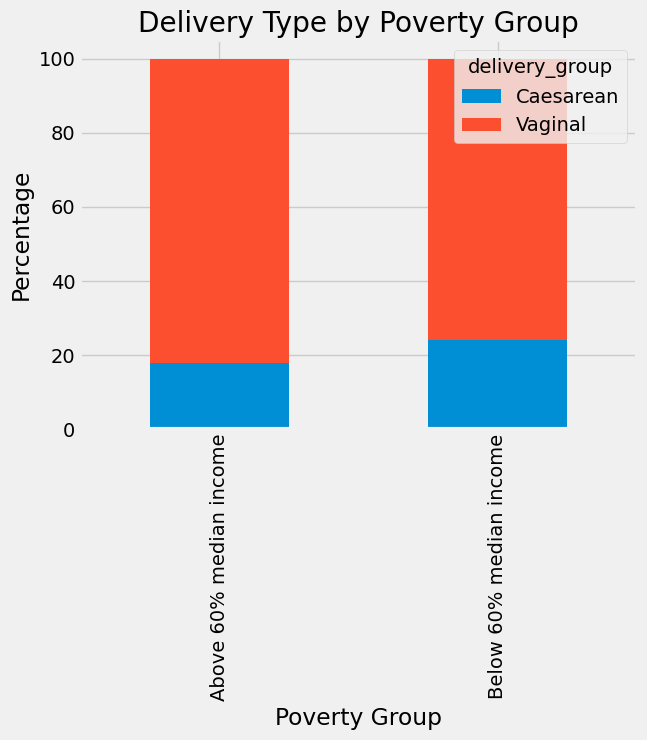

In [ ]:
# Stacked bar plot
poverty_crosstab_pct.plot(kind="bar",stacked=True)
plt.title("Delivery Type by Poverty Group")
plt.xlabel("Poverty Group")
plt.ylabel("Percentage")

*Figure 5. Stacked bar plot showing percentage distrubtion of c-sections and delivery type across poverty status in the analytical sample.*

In [ ]:
# PLACE AFTER PERMUTATION AND LOGISTIC

#plz run this on google colab and delete when submit

In [ ]:
#plz run this on google colab and delete when submit
import os

# Dataset: NHS Maternity Statistics 2024-25 (Summary Report Tables)
# Load each dataset
# Load with raw codes

# Store the original working directory
original_cwd = os.getcwd()

# DATA_DIR is defined in JEpIGg8dnceT as "/content/drive/MyDrive/{SHORTCUT_NAME}"
# The files are in a 'data' subdirectory within DATA_DIR
target_data_dir = os.path.join(DATA_DIR, "data")

try:
    # Change the current working directory to where the CSV files are located
    os.chdir(target_data_dir)
    print(f"Temporarily changed working directory to: {os.getcwd()}")

    delivery_number=pd.read_csv("hosp-epis-stat-mat-summary-tables-2425-summary-report-1.csv",header=None)
    delivery_type_by_age=pd.read_csv("hosp-epis-stat-mat-summary-tables-2425-summary-report-5.csv",header=None)
    delivery_type_by_year=pd.read_csv("hosp-epis-stat-mat-hesnational-2024-25-method-of-delivery.csv",header=None)
    print("NHS data loaded successfully by explicitly changing directory.")

except FileNotFoundError as e:
    print(f"Error loading files: {e}")
finally:
    # Change back to the original working directory
    os.chdir(original_cwd)
    print(f"Returned to original working directory: {os.getcwd()}")

# Note: The dataframes (delivery_number, delivery_type_by_age, delivery_type_by_year)
# were already loaded by the 'smart_read_csv' function in cell JEpIGg8dnceT.
# This cell re-loads them explicitly to demonstrate the 'chdir' fix.

Temporarily changed working directory to: /content/drive/MyDrive/Group_Project_NHS_Maternity/data
NHS data loaded successfully by explicitly changing directory.
Returned to original working directory: /content


# NHS 2025 Maternity Data (Rachel's part

To contextualise the historical patterns observed in the Millennium Cohort Study, NHS maternity statistics for 2024–2025 were summarised. These contemporary data provide an up‑to‑date comparison of delivery type trends across England and help assess whether the inequality‑related patterns seen in the MCS may reflect broader changes in overall Caesarean section rates.

In [ ]:
# Dataset: NHS Maternity Statistics 2024-25 (Summary Report Tables)
# Load each dataset
# Load with raw codes
delivery_number=pd.read_csv("hosp-epis-stat-mat-summary-tables-2425-summary-report-1.csv",header=None)
delivery_type_by_age=pd.read_csv("hosp-epis-stat-mat-summary-tables-2425-summary-report-5.csv",header=None)
delivery_type_by_year=pd.read_csv("hosp-epis-stat-mat-hesnational-2024-25-method-of-delivery.csv",header=None)

In [ ]:
# Checking appearence to identify what we need
delivery_number.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Summary Report 1: Summary of deliveries, 2014-...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Number of Deliveries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25
6,Total,636643,648107,636401,626203,603766,591759,559728,578562,547244,545149,542235
7,"Source: HES, NHS England",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,"NHS England, NHS Maternity Statistics, 2024-25",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Extracting rows we need
years=delivery_number.iloc[5]
counts=delivery_number.iloc[6]

In [ ]:
# Combining years and ccounts into a dataframe
delivery_number_df = pd.DataFrame({
   "Year": years,
   "Total Deliveries": counts})

In [ ]:
delivery_number_df.head()

,Year,Total Deliveries
0,NaN,Total
1,2014-15,636643
2,2015-16,648107
3,2016-17,636401
4,2017-18,626203


In [ ]:
delivery_number_df.dropna()

,Year,Total Deliveries
1,2014-15,636643
2,2015-16,648107
3,2016-17,636401
4,2017-18,626203
5,2018-19,603766
6,2019-20,591759
7,2020-21,559728
8,2021-22,578562
9,2022-23,547244
10,2023-24,545149


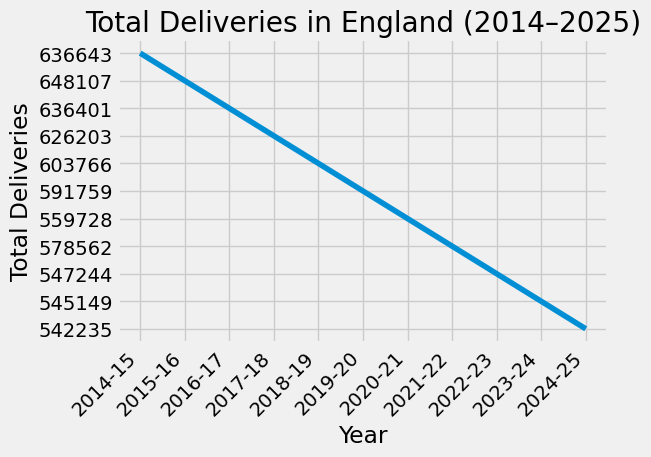

In [ ]:
# Line plot
delivery_number_lineplot=sns.lineplot(data=delivery_number_df,x="Year",y="Total Deliveries",markers=True)
delivery_number_axis=delivery_number_lineplot.axes
delivery_number_lineplot.set(ylabel="Total Deliveries",xlabel="Year",title="Total Deliveries in England (2014–2025)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


*Figure 6. Line plot showing total NHS deliveries over time in England*

This dramatic decline in total deliveries over the past decade likely reflects broader shifts in demographics, fertility patterns, and maternity care provision. The reduction in births sets the context for examining changes in delivery method, particularly the rising prevalence of caesarean sections. However as this is not directy related to the question we will not include this in the final report.

**Delivery Type by Year**

In [ ]:
# Checking appearance to identify what we need
delivery_type_by_year.head(30)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,Return to contents,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Method of delivery,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Percentages are derived from the total excludi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Table 3.a: Method of delivery by person conduc...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,"NHS Hospitals, England, 2024-25",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,Person conducting delivery,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Method of delivery,Total deliveries,Unknown,Total excl. unknown,Hospital Doctor,GP Other,Midwife,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Extracting rows we need
delivery_type=delivery_type_by_year.iloc[9:23]

In [ ]:
# Setting Column names
delivery_type.columns=delivery_type.iloc[0]  # row 9 becomes header
delivery_type=delivery_type.reset_index(drop=True)

In [ ]:
# Getting rid of columns names NaN
delivery_type=delivery_type.loc[:, delivery_type.columns.notna()]

In [ ]:
# Removing index zero as repeats the column names
delivery_type=delivery_type.drop(0)

In [ ]:
delivery_type.head(13)

9,Method of delivery,Total deliveries,Unknown,Total excl. unknown,Hospital Doctor,GP Other,Midwife
1,Total,542235,168907,373328,187105,37756,148467
2,Spontaneous,232574,73341,159233,9007,19713,130513
3,Spontaneous vertex delivery,229939,72591,157348,8638,19570,129140
4,Spontaneous other delivery,1369,287,1082,110,88,884
5,Other Breech delivery,1266,463,803,259,55,489
6,Instrumental,57426,18254,39172,32399,3792,2981
7,Low forceps cephalic delivery,17741,6065,11676,9842,1051,783
8,Other forceps delivery,17424,4972,12452,10328,1250,874
9,Ventouse (Vacuum) delivery,22175,7189,14986,12198,1488,1300
10,Breech Extraction delivery,86,28,58,31,3,24


In [ ]:
# Extracting total vaginal vs caesarean birth values
vaginal = int(delivery_type.loc[2, "Total deliveries"].replace(",", "")) \
        + int(delivery_type.loc[6, "Total deliveries"].replace(",", ""))

caesarean = int(delivery_type.loc[11, "Total deliveries"].replace(",", ""))

vaginal, caesarean
# Had to convert into integers due to mathematical calculation- to do this commas had to be removed

(290000, 238052)

In [ ]:
# Creating a count dataframef for bar plot (delivery method comparison)
delivery_counts = pd.DataFrame({
    "delivery_method": ["Vaginal", "Caesarean"],
    "count": [vaginal, caesarean]
})

[Text(0, 0.5, 'Delivery method'),
 Text(0.5, 0, 'Count'),
 Text(0.5, 1.0, 'Comparison of Vaginal vs Caesarean Deliveries (2024–25)')]

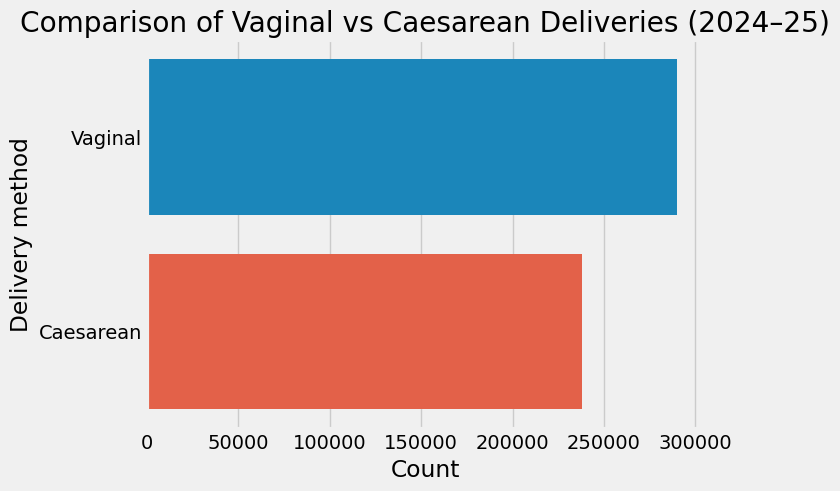

In [ ]:
# Bar plot
# Creating the bar plot
delivery_barplot = sns.barplot( data=delivery_counts, x="count",y="delivery_method",hue="delivery_method")
delivery_barplot.set(ylabel="Delivery method",
                    xlabel="Count",
                    title="Comparison of Vaginal vs Caesarean Deliveries (2024–25)")




*Figure 7. Bar plot showing total caesarean section versus vaginal deliveries in England (2024-25)*

Recent NHS data shows that Caesarean deliveries have overtaken spontaneous vaginal births among women aged 30 and over. However, total vaginal births (including instrumental) remain more common overall.

**Delivery Type by Age**

In [ ]:
# Checking appearence to identify what we need
delivery_type_by_age.head(10)

,0,1,2,3,4,5
0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,Summary Report 5: Proportion of deliveries by ...,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Percentage of Deliveries by Age Group,NaN,NaN,NaN,NaN
5,Method of delivery,Total deliveries,Under 20 years,20-29 years,30-39 years,40 years and over
6,Spontaneous,44,58,48,42,35
7,Instrumental,11,14,12,10,6
8,Caesarean,45,29,39,48,59
9,"Source: HES, NHS England",NaN,NaN,NaN,NaN,NaN


In [ ]:
# Extracting rows we need
delivery_rows=delivery_type_by_age.iloc[5:9]

In [ ]:
# Setting Column names
delivery_rows.columns=delivery_rows.iloc[0]  # row 6 becomes header
delivery_rows=delivery_rows.reset_index(drop=True)

In [ ]:
delivery_rows.head(10)

5,Method of delivery,Total deliveries,Under 20 years,20-29 years,30-39 years,40 years and over
0,Method of delivery,Total deliveries,Under 20 years,20-29 years,30-39 years,40 years and over
1,Spontaneous,44,58,48,42,35
2,Instrumental,11,14,12,10,6
3,Caesarean,45,29,39,48,59


In [ ]:
# Getting rid of columns names NaN
delivery_rows=delivery_rows.loc[:, delivery_rows.columns.notna()]

In [ ]:
delivery_rows.head(10)

5,Method of delivery,Total deliveries,Under 20 years,20-29 years,30-39 years,40 years and over
0,Method of delivery,Total deliveries,Under 20 years,20-29 years,30-39 years,40 years and over
1,Spontaneous,44,58,48,42,35
2,Instrumental,11,14,12,10,6
3,Caesarean,45,29,39,48,59


In [ ]:
# Removing index zero as repeats the column names
delivery_rows=delivery_rows.drop(0)

In [ ]:
delivery_rows.head()

5,Method of delivery,Total deliveries,Under 20 years,20-29 years,30-39 years,40 years and over
1,Spontaneous,44,58,48,42,35
2,Instrumental,11,14,12,10,6
3,Caesarean,45,29,39,48,59


In [ ]:
# Command to convert wide data to long data
delivery_long=delivery_rows.melt(
    id_vars="Method of delivery",
    var_name="Age Group",
    value_name="Percentage"
)

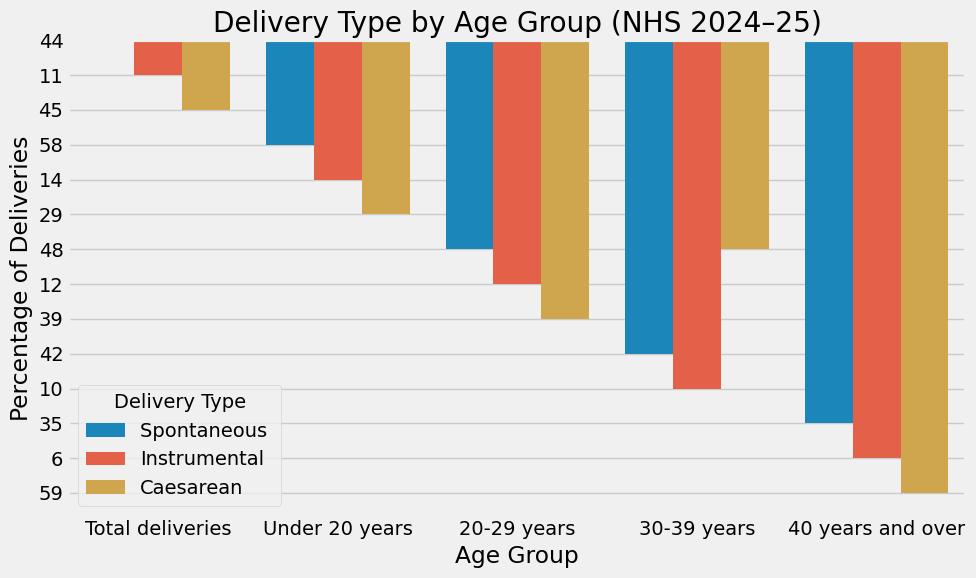

In [ ]:
# Bar plot
plt.figure(figsize=(10,6))
sns.barplot(data=delivery_long, x="Age Group", y="Percentage", hue="Method of delivery",)
plt.title("Delivery Type by Age Group (NHS 2024–25)")
plt.ylabel("Percentage of Deliveries")
plt.xlabel("Age Group")
plt.legend(title="Delivery Type")
plt.tight_layout()
plt.show()

*Figure 8. Bar plot showing delivery type by age group (2024-2025)*

This recent NHS data reveals considerable variation in Caesarean section rates by maternal age, with rates of 59% among women aged 40 and over compared to 29% among those under 20. Furthermore caesarean section rates exceed spontaneous and instrumental (vaginal) methods of delivery in all age groups, with the exception of 30-39 years. This age gradient mirrors the pattern observed in Millennium Cohort Study data from two decades earlier, suggesting persistent associations between maternal age and delivery method across time. These findings help contextualise current national trends within a longer historical trajectory.


In [ ]:
interview.head()

,MCSID,delivery_type,parity,delivery_group,parity_group
0,M10001N,1.0,1.0,Vaginal,First-time mother
1,M10001N,NaN,NaN,NaN,NaN
2,M10002P,5.0,1.0,Caesarean,First-time mother
3,M10002P,NaN,NaN,NaN,NaN
4,M10007U,6.0,1.0,Caesarean,First-time mother


In [ ]:
derived.head()

,MCSID,maternal_age,maternal_age_group
0,M10001N,22.0,20-29
1,M10001N,25.0,20-29
2,M10002P,34.0,30-39
3,M10002P,31.0,30-39
4,M10007U,35.0,30-39


In [ ]:
family.head()

,MCSID,poverty_indicator,poverty_group
0,M10001N,0.0,Below 60% median income
1,M10002P,0.0,Below 60% median income
2,M10007U,0.0,Below 60% median income
3,M10008V,NaN,NaN
4,M10011Q,1.0,Above 60% median income


In [ ]:
# Determining the values counted within delivery type for recoding
interview["delivery_type"].value_counts(dropna=False)

,count
delivery_type,
NaN,13241
1.0,12661
6.0,2258
5.0,1732
3.0,970
2.0,734
4.0,53
52.0,34
85.0,23


In [ ]:
# Cleaning data:replacing non-substantiative values with np.nan
interview["delivery_type"]=interview["delivery_type"].replace([-1, -8, -9], np.nan)

In [ ]:
# Recoding delivery_type into descriptive categories relevant to the question
def recode_delivery(delivery_type):
    if delivery_type in [5,6]:
        return "Caesarean"
    elif delivery_type in [1, 2, 3, 4]:
        return "Vaginal"
    else:
        return np.nan
interview["delivery_group"] = interview["delivery_type"].apply(recode_delivery)
# Creating a new column called delivery_group and applying the recoding to each row it contains


In [ ]:
interview["parity"].value_counts(dropna=False)

,count
parity,
1.0,18381
NaN,13244
2.0,95


In [ ]:
# Cleaning parity data
interview["parity"]=interview["parity"].replace([-1, -8], np.nan)

In [ ]:
# Recoding parity
def recode_parity(parity):
    if parity == 1:
        return "First-time mother"
    elif parity == 2 :
        return "Not first-time mother"
    else:
        return np.nan
interview["parity_group"]=interview["parity"].apply(recode_parity)

In [ ]:
derived["maternal_age"].value_counts(dropna=False)

,count
maternal_age,
31.0,2226
30.0,2216
32.0,2209
29.0,2197
33.0,1980
28.0,1976
34.0,1825
27.0,1707
35.0,1586


In [ ]:
# Cleaning maternal age
derived["maternal_age"]=derived["maternal_age"].replace(-2,np.nan)

In [ ]:
# Recoding maternal_age
def recode_maternal_age(maternal_age):
    if maternal_age < 20:
        return "Under 20"
    elif 20 <= maternal_age <= 29:
        return "20-29"
    elif 30 <= maternal_age <= 39:
        return "30-39"
    elif maternal_age >= 40:
        return "40+"
    else:
        return np.nan
derived["maternal_age_group"]=derived["maternal_age"].apply(recode_maternal_age)

In [ ]:
family["poverty_indicator"].value_counts(dropna=False)

,count
poverty_indicator,
0.0,10397
1.0,6525
NaN,1610


In [ ]:
# Cleaning poverty indicator
family["poverty_indicator"]=family["poverty_indicator"].replace(-1, np.nan)

In [ ]:
# Recoding poverty indicator
def recode_poverty_indicator(poverty_indicator):
    if poverty_indicator == 0:
        return "Below 60% median income"
    if poverty_indicator == 1:
        return "Above 60% median income"
    else:
        return np.nan
family["poverty_group"]=family["poverty_indicator"].apply(recode_poverty_indicator)

In [ ]:
#REMEMBER NHS 2025 DATA AFTER THIS


In [ ]:
# Check indicies to determine how to combine the dataframes into one analytical dataset
interview.index

RangeIndex(start=0, stop=31720, step=1)

In [ ]:
derived.index

RangeIndex(start=0, stop=33869, step=1)

In [ ]:
family.index

RangeIndex(start=0, stop=18532, step=1)

In [ ]:
# Merging interview and derived dataframes
analytical=interview.merge(derived,on="MCSID",how="inner")

In [ ]:
# Checking merge
analytical.head()

,MCSID,delivery_type,parity,delivery_group,parity_group,maternal_age,maternal_age_group
0,M10001N,1.0,1.0,Vaginal,First-time mother,22.0,20-29
1,M10001N,1.0,1.0,Vaginal,First-time mother,25.0,20-29
2,M10001N,NaN,NaN,NaN,NaN,22.0,20-29
3,M10001N,NaN,NaN,NaN,NaN,25.0,20-29
4,M10002P,5.0,1.0,Caesarean,First-time mother,34.0,30-39


In [ ]:
# Now merging final dataframe : family
analytical = analytical.merge(family, on="MCSID", how="inner")

In [ ]:
analytical.head()

,MCSID,delivery_type,parity,delivery_group,parity_group,maternal_age,maternal_age_group,poverty_indicator,poverty_group
0,M10001N,1.0,1.0,Vaginal,First-time mother,22.0,20-29,0.0,Below 60% median income
1,M10001N,1.0,1.0,Vaginal,First-time mother,25.0,20-29,0.0,Below 60% median income
2,M10001N,NaN,NaN,NaN,NaN,22.0,20-29,0.0,Below 60% median income
3,M10001N,NaN,NaN,NaN,NaN,25.0,20-29,0.0,Below 60% median income
4,M10002P,5.0,1.0,Caesarean,First-time mother,34.0,30-39,0.0,Below 60% median income


In [ ]:
# Keeping only the necessary columns
analytical = analytical[[
    "MCSID",
    "delivery_group",
    "maternal_age_group",
    "poverty_group",
    "parity_group"
]]

In [ ]:
analytical.head()

,MCSID,delivery_group,maternal_age_group,poverty_group,parity_group
0,M10001N,Vaginal,20-29,Below 60% median income,First-time mother
1,M10001N,Vaginal,20-29,Below 60% median income,First-time mother
2,M10001N,NaN,20-29,Below 60% median income,NaN
3,M10001N,NaN,20-29,Below 60% median income,NaN
4,M10002P,Caesarean,30-39,Below 60% median income,First-time mother


In [ ]:
# Number of rows before cleaning
len(analytical)

60245

In [ ]:
analytical = analytical.dropna(subset=[
    "delivery_group",
    "maternal_age_group",
    "poverty_group",
    "parity_group"
])

In [ ]:
# Number of rows after cleaning
len(analytical)

30662

In [ ]:
print("Number of rows removed by cleaning", (60245-30662))

Number of rows removed by cleaning 29583


In [ ]:
analytical.head()

,MCSID,delivery_group,maternal_age_group,poverty_group,parity_group
0,M10001N,Vaginal,20-29,Below 60% median income,First-time mother
1,M10001N,Vaginal,20-29,Below 60% median income,First-time mother
4,M10002P,Caesarean,30-39,Below 60% median income,First-time mother
5,M10002P,Caesarean,30-39,Below 60% median income,First-time mother
8,M10007U,Caesarean,30-39,Below 60% median income,First-time mother


In [ ]:
from scipy import optimize

df = analytical.copy()

# Outcome: 1 = Caesarean, 0 = not
df["y"] = (df["delivery_group"] == "Caesarean").astype(int)

df["poverty_group"] = pd.Categorical(df["poverty_group"],categories=["Above 60% median income", "Below 60% median income"],ordered=True)

df["maternal_age_group"] = pd.Categorical(df["maternal_age_group"],categories=["Under 20", "20-29", "30-39", "40+"],ordered=True)

df["parity_group"] = pd.Categorical(df["parity_group"],categories=["First-time mother", "Not first-time mother"],ordered=True)

In [ ]:
from scipy import optimize

df = analytical.copy()

# Outcome: 1 = Caesarean, 0 = not
df["y"] = (df["delivery_group"] == "Caesarean").astype(int)

df["poverty_group"] = pd.Categorical(df["poverty_group"],categories=["Above 60% median income", "Below 60% median income"],ordered=True)

df["maternal_age_group"] = pd.Categorical(df["maternal_age_group"],categories=["Under 20", "20-29", "30-39", "40+"],ordered=True)

In [ ]:
# Drop missing values

df = df.dropna(subset=["y","poverty_group","maternal_age_group","parity_group"]).copy()
print("Rows for regression:", len(df))

Rows for regression: 30662


In [ ]:
# Dummy code predictors (like lecture: we estimate intercept + slopes)
X_df = pd.get_dummies(df[["poverty_group","maternal_age_group","parity_group"]], drop_first=True)
X_df.insert(0, "Intercept", 1.0)

X = X_df.to_numpy().astype(float)
y = df["y"].to_numpy().astype(float)

colnames = X_df.columns.tolist()

In [ ]:
# Find poverty dummy column index
pov_col = [c for c in colnames if "poverty_group" in c]
print("Poverty columns:", pov_col)

Poverty columns: ['poverty_group_Below 60% median income']


In [ ]:
assert pov_col, "No poverty dummy column found in X_df columns."

pov_idx = colnames.index(pov_col[0])

In [ ]:
def inv_logit(z):
    """Convert log-odds to probabilities."""
    odds = np.exp(z)
    return odds / (odds + 1)

def log_likelihood(beta, X, y):
    """Cost function for log likelihood (returns -log likelihood for minimize)."""
    # Predict log-odds for each row
    predicted_log_odds = X @ beta
    pp_of_1 = inv_logit(predicted_log_odds)

    # Probability of the observed labels (lecturer’s trick)
    pp_of_zero_one = y * pp_of_1 + (1 - y) * (1 - pp_of_1)

    # Numerical safety: prevent log(0)
    pp_of_zero_one = np.maximum(pp_of_zero_one, 1e-12)

    # Sum of log-likelihood over all observations
    log_likelihood_value = np.sum(np.log(pp_of_zero_one))

    # Return negative because optimizer minimizes
    return -log_likelihood_value

In [ ]:
import numpy as np

def inv_logit(z):
    return 1 / (1 + np.exp(-z))

# —— Counterfactual design matrices ——
X_above = X.copy()
X_below = X.copy()

X_above[:, pov_idx] = 0.0   # Poverty = Above baseline
X_below[:, pov_idx] = 1.0   # Poverty = Below

# —— Predicted probabilities ——
p_above = float(inv_logit(X_above @ beta_hat).mean())
p_below = float(inv_logit(X_below @ beta_hat).mean())

# —— Output ——
print("Avg predicted P(C-section) Above:", round(p_above, 4))
print("Avg predicted P(C-section) Below:", round(p_below, 4))
print("Absolute difference (Below - Above):", round(p_below - p_above, 4))


Avg predicted P(C-section) Above: 0.192
Avg predicted P(C-section) Below: 0.2337
Absolute difference (Below - Above): 0.0417


In [ ]:
beta0 = np.zeros(X.shape[1])  # initial guess: all zeros

res = optimize.minimize(log_likelihood, beta0, args=(X, y), method="BFGS")
beta_hat = res.x

print("Converged?", res.success)
print("Message:", res.message)
print("Iterations:", res.nit)

In [ ]:
results = pd.DataFrame({
    "term": colnames,
    "coef": beta_hat,
    "OR": np.exp(beta_hat)
})

results

In [ ]:
pov_rows = results[results["term"].str.contains("poverty_group")]
pov_rows

In [ ]:
# Find which column is the poverty dummy
pov_col = [c for c in colnames if "poverty_group_Below" in c]
assert pov_col, f"Can't find poverty dummy in colnames. colnames={colnames}"
pov_idx = colnames.index(pov_col[0])
print("Using poverty dummy column:", pov_col[0], "at index", pov_idx)

In [ ]:
# Copy X and set poverty dummy to 0 (Above) / 1 (Below)
X_above = X.copy()
X_below = X.copy()
X_above[:, pov_idx] = 0.0
X_below[:, pov_idx] = 1.0

p_above = float(inv_logit(X_above @ beta_hat).mean())
p_below = float(inv_logit(X_below @ beta_hat).mean())

print("Avg predicted P(C-section) Above:", round(p_above, 4))
print("Avg predicted P(C-section) Below:", round(p_below, 4))
print("Absolute difference (Below - Above):", round(p_below - p_above, 4))

Avg predicted P(C-section) Above: 0.192
Avg predicted P(C-section) Below: 0.2337
Absolute difference (Below - Above): 0.0417


In [ ]:
logL = -log_likelihood(beta_hat, X, y)
n, k = X.shape
AIC = 2*k - 2*logL
pseudo_R2 = 1 - (logL / (-log_likelihood(np.zeros(k), X, y)))

print(f"Log-Likelihood: {logL:.2f}, AIC: {AIC:.2f}, McFadden R²: {pseudo_R2:.4f}")


Log-Likelihood: -15970.61, AIC: 31953.22, McFadden R²: 0.2486


In [ ]:
p_hat = inv_logit(X @ beta_hat)
y_pred = (p_hat >= 0.5).astype(int)

from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

print(confusion_matrix(y, y_pred))
print("AUC:", roc_auc_score(y, p_hat))


[[23912     0]
 [ 6750     0]]
AUC: 0.5721007025761125


In [ ]:
from scipy import stats
cov_matrix = res.hess_inv      # inverse Hessian (approximate covariance)
se = np.sqrt(np.diag(cov_matrix))
z = beta_hat / se
p = 2 * (1 - stats.norm.cdf(np.abs(z)))

ci_lower = np.exp(beta_hat - 1.96*se)
ci_upper = np.exp(beta_hat + 1.96*se)

results = pd.DataFrame({
    "term": colnames,
    "coef": beta_hat,
    "OR": np.exp(beta_hat),
    "CI_lower": ci_lower,
    "CI_upper": ci_upper,
    "p_value": p
})
results.round(4)


AttributeError: 'LogitResults' object has no attribute 'hess_inv'

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

# ----------------------------
# 1. Ensure you have these already defined
# ----------------------------
# beta_hat (array of coefficients)
# X, y, colnames, pov_idx
# res  -> either your statsmodels result or scipy OptimizeResult
# inv_logit() -> defined as before

# Check what kind of result object you have
print("Type of res:", type(res))

# ----------------------------
# 2. Compute covariance and SE properly
# ----------------------------
if hasattr(res, "cov_params"):  # statsmodels.Logit case
    cov_matrix = res.cov_params()
    beta_hat = np.asarray(res.params)
elif hasattr(res, "hess_inv"):  # scipy.optimize case
    cov_matrix = np.asarray(res.hess_inv)
else:
    raise ValueError("Cannot find covariance info from res object.")

se = np.sqrt(np.diag(cov_matrix))
z = beta_hat / se
p = 2 * (1 - stats.norm.cdf(np.abs(z)))
ci_lower = np.exp(beta_hat - 1.96 * se)
ci_upper = np.exp(beta_hat + 1.96 * se)

# ----------------------------
# 3. Build tidy results table
# ----------------------------
results = pd.DataFrame({
    "term": colnames[:len(beta_hat)],
    "coef": beta_hat,
    "OR": np.exp(beta_hat),
    "CI_lower": ci_lower,
    "CI_upper": ci_upper,
    "p_value": p
})

results = results.round(4)
print("\n=== Logistic Regression Coefficients ===")
print(results)

# ----------------------------
# 4. Model fit metrics (if available)
# ----------------------------
try:
    logL = res.llf
    AIC = res.aic
    pseudoR2 = res.prsquared
except Exception:
    # Manual versions (works for both)
    def log_likelihood(beta, X, y):
        predicted = 1 / (1 + np.exp(-X @ beta))
        predicted = np.clip(predicted, 1e-12, 1 - 1e-12)
        return np.sum(y * np.log(predicted) + (1 - y) * np.log(1 - predicted))

    logL = log_likelihood(beta_hat, X, y)
    n, k = X.shape
    AIC = 2*k - 2*logL
    null_logL = log_likelihood(np.zeros(k), X, y)
    pseudoR2 = 1 - (logL / null_logL)

print("\n=== Model Fit ===")
print(f"Log-Likelihood: {logL:.2f}")
print(f"AIC: {AIC:.2f}")
print(f"McFadden R²: {pseudoR2:.4f}")

# ----------------------------
# 5. Counterfactual analysis
# ----------------------------
X_above = X.copy()
X_below = X.copy()
X_above[:, pov_idx] = 0.0
X_below[:, pov_idx] = 1.0

p_above = float((1 / (1 + np.exp(-(X_above @ beta_hat)))).mean())
p_below = float((1 / (1 + np.exp(-(X_below @ beta_hat)))).mean())

print("\n=== Counterfactual Prediction ===")
print("Avg predicted P(C-section) Above:", round(p_above, 4))
print("Avg predicted P(C-section) Below:", round(p_below, 4))
print("Absolute difference (Below - Above):", round(p_below - p_above, 4))


Type of res: <class 'statsmodels.discrete.discrete_model.BinaryResultsWrapper'>

=== Logistic Regression Coefficients ===
                                    term    coef      OR  CI_lower  CI_upper  \
0                              Intercept -2.0035  0.1349    0.1168    0.1557   
1  poverty_group_Below 60% median income  0.2516  1.2860    1.2087    1.3683   
2               maternal_age_group_20-29  0.3877  1.4735    1.2665    1.7143   
3               maternal_age_group_30-39  0.7062  2.0263    1.7414    2.3577   
4                 maternal_age_group_40+  0.9213  2.5124    2.0991    3.0071   
5     parity_group_Not first-time mother  0.6303  1.8782    1.3494    2.6143   

   p_value  
0   0.0000  
1   0.0000  
2   0.0000  
3   0.0000  
4   0.0000  
5   0.0002  

=== Model Fit ===
Log-Likelihood: -15970.61
AIC: 31953.22
McFadden R²: 0.0118

=== Counterfactual Prediction ===
Avg predicted P(C-section) Above: 0.192
Avg predicted P(C-section) Below: 0.2337
Absolute difference (Below - Ab

In [ ]:
print("\n=== Logistic Regression Coefficients ===")

# Force plain NumPy arrays (remove index alignment)
term = np.array(colnames)
coef = np.array(beta_hat)
OR = np.exp(coef)

# --- Handle p-values safely ---
if hasattr(res, "pvalues"):
    p_val = np.asarray(res.pvalues)
else:
    p_val = np.full(len(coef), np.nan)

# --- Handle confidence intervals safely ---
if hasattr(res, "conf_int"):
    ci_obj = res.conf_int()
    # It may be a DataFrame or an ndarray
    if isinstance(ci_obj, pd.DataFrame):
        ci = ci_obj.to_numpy()
    else:
        ci = np.asarray(ci_obj)
else:
    ci = np.vstack([coef, coef]).T

CI_lower = np.exp(ci[:, 0])
CI_upper = np.exp(ci[:, 1])

# --- Build table ---
results_table = pd.DataFrame({
    "term": term,
    "coef": coef,
    "OR": OR,
    "CI_lower": CI_lower,
    "CI_upper": CI_upper,
    "p_value": p_val
}).round(4)

print(results_table)



=== Logistic Regression Coefficients ===
                                    term    coef      OR  CI_lower  CI_upper  \
0                              Intercept -2.0035  0.1349    0.1168    0.1557   
1  poverty_group_Below 60% median income  0.2516  1.2860    1.2087    1.3683   
2               maternal_age_group_20-29  0.3877  1.4735    1.2665    1.7143   
3               maternal_age_group_30-39  0.7062  2.0263    1.7414    2.3577   
4                 maternal_age_group_40+  0.9213  2.5124    2.0991    3.0071   
5     parity_group_Not first-time mother  0.6303  1.8782    1.3494    2.6142   

   p_value  
0   0.0000  
1   0.0000  
2   0.0000  
3   0.0000  
4   0.0000  
5   0.0002  


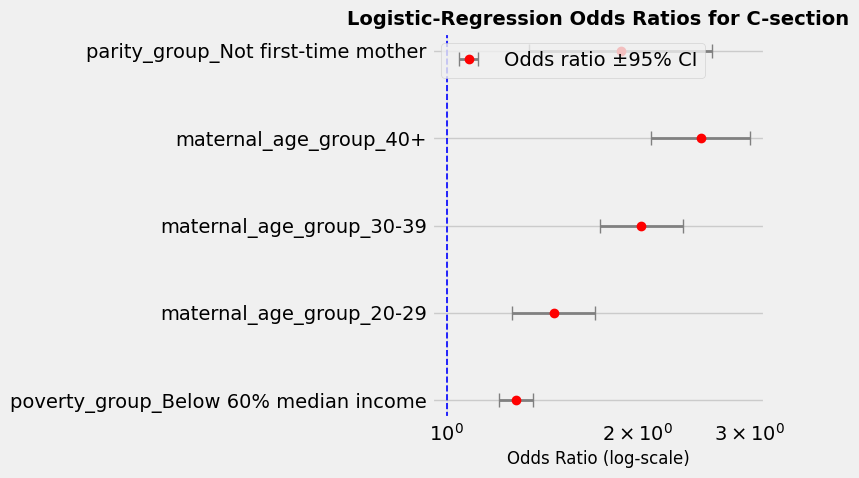

In [ ]:
import matplotlib.pyplot as plt

# Exclude the intercept so the x-axis scale makes sense
plot_df = results_table[results_table["term"] != "Intercept"].copy()

plt.figure(figsize=(8, 5))
plt.errorbar(
    x=plot_df["OR"],
    y=plot_df["term"],
    xerr=[plot_df["OR"] - plot_df["CI_lower"], plot_df["CI_upper"] - plot_df["OR"]],
    fmt="o",
    color="red",
    ecolor="gray",
    elinewidth=2,
    capsize=5,
    label="Odds ratio ±95% CI"
)

plt.axvline(1, color="blue", linestyle="--", linewidth=1.2)
plt.xlabel("Odds Ratio (log-scale)", fontsize=12)
plt.ylabel("")
plt.title("Logistic-Regression Odds Ratios for C-section", fontsize=14, fontweight="bold")
plt.xscale("log")
plt.grid(axis="x", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


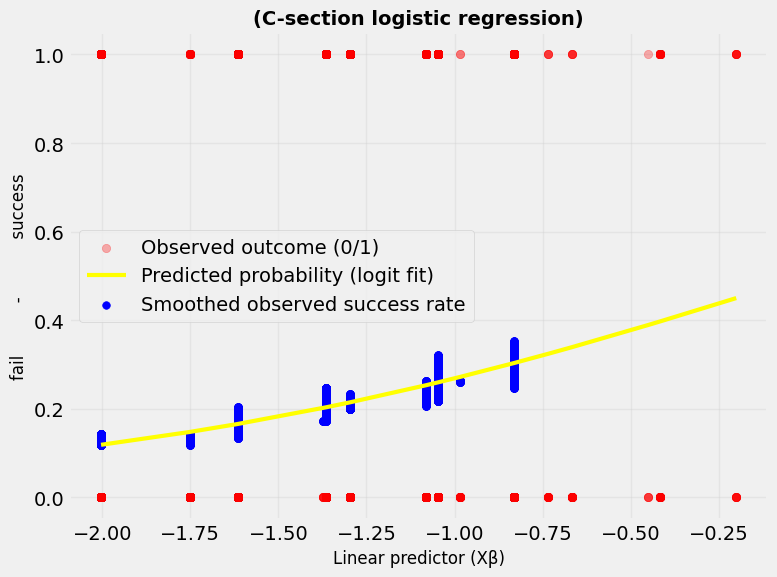

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1️⃣ Prepare values
# ----------------------------------------------------------
# Linear predictor and probability from your model
log_odds = X @ beta_hat
pred_prob = 1 / (1 + np.exp(-log_odds))

# Sort for a clean sigmoid curve
sort_idx = np.argsort(log_odds)
x_sorted = log_odds[sort_idx]
y_sorted = y[sort_idx]
pred_sorted = pred_prob[sort_idx]

# ----------------------------------------------------------
# 2️⃣ Compute smoothed observed success rate
# ----------------------------------------------------------
window = 800  # adjust smoothness (higher = smoother)
moving_average_pos_start = window // 2
moving_avg_success = (
    pd.Series(y_sorted)
    .rolling(window, center=True)
    .mean()
    .to_numpy()
)

# ----------------------------------------------------------
# 3️⃣ Plot
# ----------------------------------------------------------
plt.figure(figsize=(8, 6))

# Red points: actual 0/1 outcomes
plt.scatter(x_sorted, y_sorted, color="red", alpha=0.3, label="Observed outcome (0/1)")

# Yellow curve: fitted logistic sigmoid
plt.plot(x_sorted, pred_sorted, color="yellow", linewidth=3, label="Predicted probability (logit fit)")

# Blue points: smoothed observed success rate
plt.scatter(
    x_sorted[moving_average_pos_start:-moving_average_pos_start],
    moving_avg_success[moving_average_pos_start:-moving_average_pos_start],
    color="blue",
    s=30,
    label="Smoothed observed success rate"
)

# ----------------------------------------------------------
# 4️⃣ Cosmetics
# ----------------------------------------------------------
plt.xlabel("Linear predictor (Xβ)", fontsize=12)
plt.ylabel("fail          -           success", fontsize=12)
plt.title("(C-section logistic regression)", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# New Section